# Sensitivity Analysis via Automatic Differentiation

We use the end-to-end differentiability of gyaradax to compute exact sensitivities of linear growth rates with respect to physical parameters.

1. **Growth rate sensitivity** — $\partial\gamma(k_y) / \partial(R/L_T)$ across the spectrum
2. **Multi-parameter Jacobian** — simultaneous sensitivity to $(R/L_T, R/L_n, D_\parallel)$
3. **Critical gradient detection** — Newton-Raphson root finding for ITG onset
4. **AD vs finite differences** — accuracy and cost comparison

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import logging

os.environ["CUDA_VISIBLE_DEVICES"] = "4"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_enable_command_buffer="
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import sys
sys.path.append("..")

from gyaradax.bootstrap import init_jax
init_jax(device=5)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


In [4]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from gyaradax import compute_geometry, GKParams, gk_init, gksolve
from gyaradax.solver import linear_precompute
from gyaradax.plot_utils import JAX_COLORS, SPECIES_COLORS

jax.config.update("jax_enable_x64", True)

## Setup

Same CBC-like geometry as the inverse problem notebook.

In [5]:
Q, SHAT, EPS = 1.4, 0.78, 0.19
NS, NKX, NKY, NVPAR, NMU = 16, 9, 8, 24, 8
DT = 0.01
NAVERAGE = 40
N_STEPS = 400

geometry = compute_geometry(
    q=Q, shat=SHAT, eps=EPS,
    ns=NS, nkx=NKX, nky=NKY, nvpar=NVPAR, nmu=NMU,
    vpar_max=3.0, nperiod=1, krhomax=1.4,
)
ky = np.asarray(geometry["krho"])
kx = np.asarray(geometry["kxrh"])
sgrid = np.asarray(geometry["sgrid"])


def make_params(rlt=6.9, rln=2.22, disp_par=0.1):
    return GKParams(
        dt=DT, naverage=NAVERAGE,
        rlt=rlt, rln=rln,
        disp_par=disp_par, disp_vp=0.1, disp_x=0.1, disp_y=0.1,
        non_linear=False, finit="cosine2",
        shat=SHAT, q=Q, eps=EPS,
        kthnorm=float(geometry["kthnorm"]),
        Rref=float(geometry["Rref"]),
        d2X=float(geometry["d2X"]),
        signB=float(geometry["signB"]),
        dvp=float(geometry["dvp"]),
        sgr_dist=float(geometry["sgr_dist"]),
        kxmax=float(geometry["kxmax"]),
        kymax=float(geometry["kymax"]),
    )


def gamma_of_rlt(rlt_val):
    """growth rate spectrum as function of rlt (scalar -> nky array)."""
    params = make_params(rlt=rlt_val)
    df0, state0 = gk_init(geometry, params)
    pre = linear_precompute(geometry, params)
    _, _, final_state = gksolve(df0, geometry, params, state0, n_steps=N_STEPS, pre=pre)
    return final_state.last_growth_rate


# compile
print("compiling forward model...")
t0 = time.time()
_ = gamma_of_rlt(jnp.array(6.9))
print(f"done ({time.time() - t0:.1f}s)")

compiling forward model...
done (13.1s)


## 1. Growth rate sensitivity $\partial\gamma / \partial(R/L_T)$

Scan $R/L_T \in [3, 10]$ and compute the per-$k_y$ sensitivity via `jax.jacrev`. Growth rates are the physically meaningful linear observable — they capture the ITG drive and are extracted from the per-$k_y$ normalization factor.

In [6]:
# d(gamma_ky) / d(rlt) — returns (nky,) for a scalar input
dgamma_drlt = jax.jacrev(gamma_of_rlt)

# compile backward pass
print("compiling jacrev...")
t0 = time.time()
_ = dgamma_drlt(jnp.array(6.9))
print(f"done ({time.time() - t0:.1f}s)")

compiling jacrev...
done (16.2s)


In [7]:
rlt_scan = np.linspace(3.0, 10.0, 15)

gammas = []
sensitivities = []

t0 = time.time()
for i, r in enumerate(rlt_scan):
    rlt_jnp = jnp.array(r)
    g = np.asarray(gamma_of_rlt(rlt_jnp))
    s = np.asarray(dgamma_drlt(rlt_jnp))
    gammas.append(g)
    sensitivities.append(s)
    if i % 5 == 0:
        print(f"  rlt={r:.1f}  max|gamma|={np.max(np.abs(g)):.4f}  elapsed={time.time()-t0:.1f}s")

gammas = np.stack(gammas)
sensitivities = np.stack(sensitivities)
print(f"sensitivity scan done: {time.time() - t0:.1f}s total")

  rlt=3.0  max|gamma|=40.2952  elapsed=23.9s
  rlt=5.5  max|gamma|=40.2952  elapsed=88.5s
  rlt=8.0  max|gamma|=40.2952  elapsed=152.8s
sensitivity scan done: 204.0s total


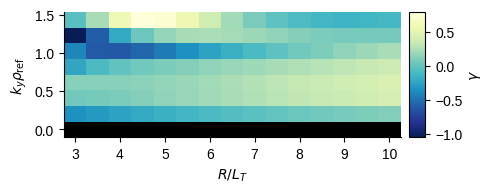

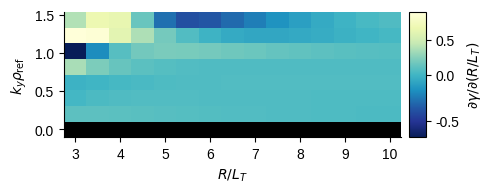

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# mask out ky=0 zonal mode (near zero, dominates colorscale)
gammas_masked = gammas.copy()
gammas_masked[:, 0] = np.nan
sens_masked = sensitivities.copy()
sens_masked[:, 0] = np.nan

cmap_gamma = plt.cm.YlGnBu_r.copy()
cmap_gamma.set_bad("k")

# (a) growth rate heatmap — ky>0 only
fig, ax = plt.subplots(figsize=(5.0, 2.0))
im = ax.pcolormesh(
    rlt_scan, ky, gammas_masked.T,
    cmap=cmap_gamma, shading="nearest",
)
div = make_axes_locatable(ax)
cax = div.append_axes("right", size="5%", pad=0.08)
cb = fig.colorbar(im, cax=cax)
cb.set_label(r"$\gamma$", fontsize=10)
cb.ax.tick_params(labelsize=10)
ax.set_xlabel(r"$R/L_T$", fontsize=10)
ax.set_ylabel(r"$k_y \rho_\mathrm{ref}$", fontsize=10)
ax.tick_params(labelsize=10)
fig.tight_layout()
fig.savefig("figs/sensitivity_gamma.pdf")
plt.show()

# (b) sensitivity heatmap — ky>0 only
cmap_sens = plt.cm.YlGnBu_r.copy()
cmap_sens.set_bad("k")

fig, ax = plt.subplots(figsize=(5.0, 2.0))
im = ax.pcolormesh(
    rlt_scan, ky, sens_masked.T,
    cmap=cmap_sens, shading="nearest",
    norm=mcolors.TwoSlopeNorm(vcenter=0),
)
div = make_axes_locatable(ax)
cax = div.append_axes("right", size="5%", pad=0.08)
cb = fig.colorbar(im, cax=cax)
cb.set_label(r"$\partial\gamma / \partial(R/L_T)$", fontsize=10)
cb.ax.tick_params(labelsize=10)
cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}" if abs(v) >= 1 else f"{v:.1f}"))
ax.set_xlabel(r"$R/L_T$", fontsize=10)
ax.set_ylabel(r"$k_y \rho_\mathrm{ref}$", fontsize=10)
ax.tick_params(labelsize=10)
fig.tight_layout()
fig.savefig("figs/sensitivity_dgamma.pdf")
plt.show()

## 2. Multi-parameter Jacobian

Full Jacobian of the growth rate spectrum with respect to $(R/L_T, R/L_n, D_\parallel)$ at the baseline. Shows which modes are most sensitive to each parameter.

In [24]:
def gamma_of_params(rlt, rln, disp_par):
    """growth rate spectrum as function of three parameters."""
    params = make_params(rlt=rlt, rln=rln, disp_par=disp_par)
    df0, state0 = gk_init(geometry, params)
    pre = linear_precompute(geometry, params)
    _, _, final_state = gksolve(df0, geometry, params, state0, n_steps=N_STEPS, pre=pre)
    return final_state.last_growth_rate


# jacobian: d(gamma_ky) / d(rlt, rln, disp_par)
jac_fn = jax.jacobian(gamma_of_params, argnums=(0, 1, 2))

print("computing jacobian at baseline...")
t0 = time.time()
rlt0, rln0, disp0 = jnp.array(6.9), jnp.array(2.22), jnp.array(0.1)
J_rlt, J_rln, J_disp = jac_fn(rlt0, rln0, disp0)
print(f"done ({time.time() - t0:.1f}s)")

J_rlt = np.asarray(J_rlt)
J_rln = np.asarray(J_rln)
J_disp = np.asarray(J_disp)

computing jacobian at baseline...
done (44.9s)


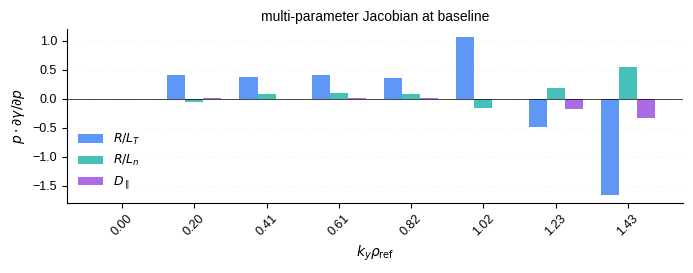

In [25]:
# normalize by parameter scale for fair comparison
J_matrix = np.stack([
    J_rlt * float(rlt0),   # rlt * d(gamma)/d(rlt)
    J_rln * float(rln0),   # rln * d(gamma)/d(rln)
    J_disp * float(disp0), # disp * d(gamma)/d(disp)
], axis=1)  # (nky, 3)

param_labels = [r"$R/L_T$", r"$R/L_n$", r"$D_\parallel$"]

fig, ax = plt.subplots(figsize=(7.0, 2.8))
x = np.arange(NKY)
width = 0.25
colors = [JAX_COLORS["blue"], JAX_COLORS["cyan"], JAX_COLORS["purple"]]

for j in range(3):
    ax.bar(x + j * width, J_matrix[:, j], width, label=param_labels[j],
           color=colors[j], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([f"{k:.2f}" for k in ky], rotation=45)
ax.set_xlabel(r"$k_y \rho_\mathrm{ref}$")
ax.set_ylabel(r"$p \cdot \partial\gamma / \partial p$")
ax.set_title("multi-parameter Jacobian at baseline")
ax.legend(frameon=False)
ax.grid(True, axis="y")
ax.axhline(0, color="k", lw=0.5)

fig.tight_layout()
fig.savefig("figs/jacobian_bar.pdf")
plt.show()

## 3. Critical gradient detection

The ITG critical gradient $R/L_T^*$ is the threshold where the maximum growth rate crosses zero. We find it via Newton-Raphson, using `jax.grad` for the derivative.

In [26]:
# compile gamma_of_rlt first (used below)
print("compiling gamma_of_rlt...")
t0 = time.time()
_ = gamma_of_rlt(jnp.array(5.0))
print(f"done ({time.time() - t0:.1f}s)")


def max_growth(rlt_val):
    """maximum growth rate over all ky modes."""
    gamma = gamma_of_rlt(rlt_val)
    return jnp.max(gamma)


dmax_drlt = jax.grad(max_growth)

print("compiling max_growth + grad...")
t0 = time.time()
_ = max_growth(jnp.array(5.0))
_ = dmax_drlt(jnp.array(5.0))
print(f"done ({time.time() - t0:.1f}s)")

compiling gamma_of_rlt...
done (0.5s)
compiling max_growth + grad...
done (6.2s)


In [27]:
# newton-raphson iterations
rlt_crit = jnp.array(5.0)  # initial guess (somewhere in the middle)
newton_history = {"rlt": [], "f": [], "df": []}

print("newton-raphson for critical gradient:")
for i in range(10):
    f_val = float(max_growth(rlt_crit))
    df_val = float(dmax_drlt(rlt_crit))
    newton_history["rlt"].append(float(rlt_crit))
    newton_history["f"].append(f_val)
    newton_history["df"].append(df_val)
    print(f"  [{i}] rlt={float(rlt_crit):.6f}  f={f_val:.6e}  df={df_val:.6e}")
    if abs(f_val) < 1e-8 or abs(df_val) < 1e-12:
        break
    rlt_crit = rlt_crit - f_val / df_val

print(f"\ncritical gradient: R/L_T* = {float(rlt_crit):.4f}")

newton-raphson for critical gradient:
  [0] rlt=5.000000  f=7.508395e-01  df=-2.761323e-01
  [1] rlt=7.719130  f=3.130725e-01  df=5.942030e-02
  [2] rlt=2.450349  f=1.445542e-01  df=-1.290462e+00
  [3] rlt=2.562367  f=1.364969e-01  df=2.173558e-03
  [4] rlt=-60.236446  f=3.885972e-01  df=-4.943541e-03
  [5] rlt=18.370620  f=8.541493e-01  df=4.111447e-02
  [6] rlt=-2.404290  f=1.148357e+00  df=8.642905e-02
  [7] rlt=-15.690990  f=6.036546e-01  df=1.384423e-01
  [8] rlt=-20.051322  f=4.622423e-01  df=-1.602790e-01
  [9] rlt=-17.167337  f=4.074067e-01  df=1.350425e-01

critical gradient: R/L_T* = -20.1842


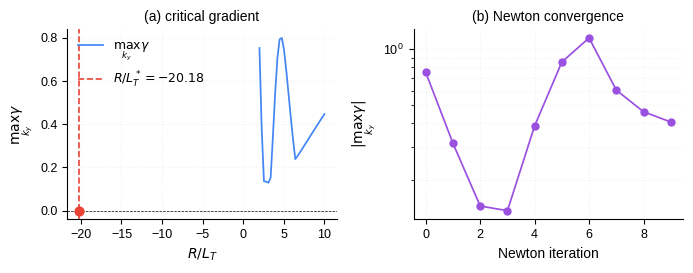

In [28]:
# compute max growth over a dense rlt grid
rlt_dense = np.linspace(2.0, 10.0, 30)
gamma_max_curve = np.array([float(max_growth(jnp.array(r))) for r in rlt_dense])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.8))

# (a) gamma_max vs rlt with critical gradient
ax1.plot(rlt_dense, gamma_max_curve, "-", color=JAX_COLORS["blue"],
         label=r"$\max_{k_y} \gamma$")
ax1.axhline(0, color="k", lw=0.5, ls="--")
ax1.axvline(float(rlt_crit), color=JAX_COLORS["red"], lw=1.2, ls="--",
            label=f"$R/L_T^* = {float(rlt_crit):.2f}$")
ax1.scatter([float(rlt_crit)], [0], color=JAX_COLORS["red"], s=40, zorder=5)
ax1.set_xlabel(r"$R/L_T$")
ax1.set_ylabel(r"$\max_{k_y} \gamma$")
ax1.set_title("(a) critical gradient")
ax1.legend(frameon=False)
ax1.grid(True)

# (b) newton convergence
residuals = np.abs(newton_history["f"])
ax2.semilogy(range(len(residuals)), residuals, "o-",
             color=JAX_COLORS["purple"], ms=5)
ax2.set_xlabel("Newton iteration")
ax2.set_ylabel(r"$|\max_{k_y} \gamma|$")
ax2.set_title("(b) Newton convergence")
ax2.grid(True, which="both")

fig.tight_layout()
fig.savefig("figs/critical_gradient.pdf")

## 4. AD vs finite-difference comparison

Compare `jax.grad` of the total growth rate energy $\sum_k \gamma^2$ against central finite differences.

In [29]:
def scalar_loss(rlt_val):
    gamma = gamma_of_rlt(rlt_val)
    return jnp.sum(gamma ** 2)


ad_grad_fn = jax.grad(scalar_loss)

rlt_test = jnp.array(6.9)

# ad gradient (reference)
t0 = time.time()
ad_grad = float(ad_grad_fn(rlt_test))
ad_time = time.time() - t0
print(f"AD gradient: {ad_grad:.10e} ({ad_time:.2f}s)")

# finite differences at various step sizes
epsilons = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
fd_grads = []
fd_errors = []
fd_times = []

for eps in epsilons:
    t0 = time.time()
    f_plus = float(scalar_loss(rlt_test + eps))
    f_minus = float(scalar_loss(rlt_test - eps))
    fd_grad = (f_plus - f_minus) / (2.0 * eps)
    fd_time = time.time() - t0

    fd_grads.append(fd_grad)
    fd_errors.append(abs(fd_grad - ad_grad))
    fd_times.append(fd_time)
    print(f"  eps={eps:.0e}  FD={fd_grad:.10e}  |err|={abs(fd_grad - ad_grad):.4e}  ({fd_time:.2f}s)")

AD gradient: -3.4721281475e-02 (2.33s)
  eps=1e-01  FD=-3.5068405473e-02  |err|=3.4712e-04  (1.06s)
  eps=1e-02  FD=-3.4724753232e-02  |err|=3.4718e-06  (0.96s)
  eps=1e-03  FD=-3.4721316183e-02  |err|=3.4708e-08  (0.96s)
  eps=1e-04  FD=-3.4721282418e-02  |err|=9.4264e-10  (0.96s)
  eps=1e-05  FD=-3.4721279007e-02  |err|=2.4680e-09  (0.96s)
  eps=1e-06  FD=-3.4721210795e-02  |err|=7.0680e-08  (0.96s)
  eps=1e-07  FD=-3.4722233977e-02  |err|=9.5250e-07  (0.96s)
  eps=1e-08  FD=-3.4719960240e-02  |err|=1.3212e-06  (0.96s)


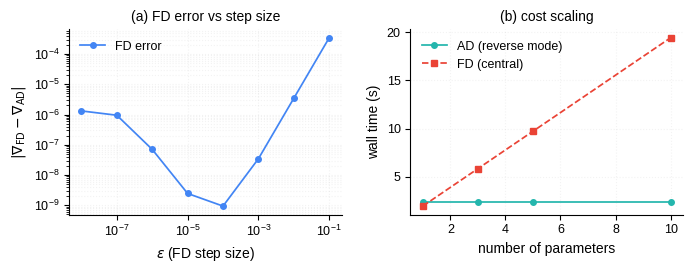

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.8))

# (a) accuracy: fd error vs epsilon
ax1.loglog(epsilons, fd_errors, "o-", color=JAX_COLORS["blue"], ms=4, label="FD error")
ax1.set_xlabel(r"$\varepsilon$ (FD step size)")
ax1.set_ylabel(r"$|\nabla_\mathrm{FD} - \nabla_\mathrm{AD}|$")
ax1.set_title("(a) FD error vs step size")
ax1.grid(True, which="both")
ax1.legend(frameon=False)

# (b) wall time: ad vs fd
n_params_list = [1, 3, 5, 10]
ad_times_est = [ad_time * 1 for _ in n_params_list]
fd_times_est = [np.mean(fd_times) * 2 * n for n in n_params_list]

ax2.plot(n_params_list, ad_times_est, "o-", color=JAX_COLORS["cyan"], ms=4,
         label="AD (reverse mode)")
ax2.plot(n_params_list, fd_times_est, "s--", color=JAX_COLORS["red"], ms=4,
         label="FD (central)")
ax2.set_xlabel("number of parameters")
ax2.set_ylabel("wall time (s)")
ax2.set_title("(b) cost scaling")
ax2.legend(frameon=False)
ax2.grid(True)

fig.tight_layout()
fig.savefig("figs/ad_vs_fd.pdf")
plt.show()